# TSMOM Realtime Backtest (Production)

Realtime time-series momentum with state-conditional dynamic blending. Configuration lives in `config.py`.

**Strategies compared:**
- **Dynamic**: eq.(7) state-conditional blending of slow/fast trend
- **Static**: `sign(x_slow) · r`, paper's baseline
- **Buy & Hold (1/N)**: equal-weight long-only benchmark

All three portfolios are aggregated and vol-scaled with identical settings (per `config.py`) so Sharpe/return comparisons are apples-to-apples.

## 1. Setup & Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import yfinance as yf
from importlib import reload

import tsmom; reload(tsmom)
import config; reload(config)

from tsmom import (
    momentum_signals, classify_states,
    static_trend_returns, dynamic_trend_returns, dynamic_trend_positions,
    estimate_mixing_params, scaled_portfolio,
    annualized_stats, max_drawdown, run_backtest,
    build_weights, compute_turnover, apply_tcost, annualized_turnover,
)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.family"] = "DejaVu Sans"

cfg = config
print("=== Configuration ===")
print(f"Universe: {len(cfg.TICKERS)} assets")
for t, lbl in cfg.TICKERS.items():
    print(f"  {t:6s} {lbl}")
print(f"\nSlow/Fast lookback: {cfg.K_SLOW}M / {cfg.K_FAST}M")
print(f"Vol scaling: {cfg.VOL_SCALING}")
if cfg.VOL_SCALING:
    print(f"  Level : {cfg.SCALE_LEVEL}")
    print(f"  Mode  : {cfg.VOL_MODE}")
    print(f"  Target: {cfg.TARGET_VOL:.0%}")
    print(f"  Window: {cfg.VOL_LOOKBACK}M rolling")
print(f"Transaction cost: {cfg.TCOST_BPS:.1f} bps round-trip (applied to one-way turnover)")

=== Configuration ===
Universe: 21 assets
  SMH    Semiconductors
  IGV    Software
  XAR    Aerospace
  XBI    Biotech
  XME    Metals&Mining
  GDX    GoldMiners
  XOP    Oil&Gas
  PAVE   InfraDev
  MGK    Growth
  MGV    Value
  IWM    Small
  SCHD   Dividend
  USMV   MinVol
  MTUM   Momentum
  QUAL   Quality
  372330.KS HangSengTech
  487230.KS AI-Power
  BOTZ   Robot
  SKYY   CloudComputing
  ICLN   CleanEnergy
  AIQ    AI-Tech

Slow/Fast lookback: 12M / 2M
Vol scaling: True
  Level : portfolio
  Mode  : realtime
  Target: 10%
  Window: 36M rolling
Transaction cost: 20.0 bps round-trip (applied to one-way turnover)


## 2. Data

In [2]:
tickers = list(cfg.TICKERS.keys())
prices = yf.download(tickers, start=cfg.START_DATE, end=cfg.END_DATE,
                     auto_adjust=True, progress=False)["Close"]
prices = prices.dropna(axis=1, how="all")
# Ensure column order matches config
prices = prices[[t for t in tickers if t in prices.columns]]

monthly_prices = prices.resample("ME").last()
returns = monthly_prices.pct_change().dropna(how="all")

print(f"Period: {returns.index[0].strftime('%Y-%m')} → {returns.index[-1].strftime('%Y-%m')}")
print(f"Assets: {returns.shape[1]}  |  Months: {returns.shape[0]}")
returns.tail(3).round(4)

Period: 2006-02 → 2026-04
Assets: 21  |  Months: 243


Ticker,SMH,IGV,XAR,XBI,XME,GDX,XOP,PAVE,MGK,MGV,...,SCHD,USMV,MTUM,QUAL,372330.KS,487230.KS,BOTZ,SKYY,ICLN,AIQ
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-28,0.0072,-0.0968,0.0366,0.0210,0.0053,0.2297,0.0961,0.0855,-0.0466,0.0331,...,0.0654,0.0297,-0.0115,0.0121,-0.1024,0.1219,0.0456,-0.0796,0.0039,-0.0329
2026-03-31,-0.0565,-0.0186,-0.1020,0.0028,-0.0945,-0.2078,0.1876,-0.0777,-0.0496,-0.0481,...,-0.0261,-0.0479,-0.0504,-0.0617,-0.0426,-0.0449,-0.1486,-0.0026,0.0038,-0.0714
2026-04-30,0.3209,0.0643,0.0097,0.0435,0.0905,0.0280,-0.0758,0.1041,0.1466,0.0354,...,0.0169,0.0144,0.1705,0.0813,0.0284,0.3148,0.1246,0.0839,0.0929,0.1815


## 3. Backtest

In [3]:
target_vol = cfg.TARGET_VOL if cfg.VOL_SCALING else None

result = run_backtest(
    returns,
    k_slow=cfg.K_SLOW,
    k_fast=cfg.K_FAST,
    target_vol=target_vol,
    vol_mode=cfg.VOL_MODE,
    scale_level=cfg.SCALE_LEVEL,
    vol_lookback=cfg.VOL_LOOKBACK,
    tcost_bps=cfg.TCOST_BPS,
)

# --- Positions for all 5 strategies ---
def sign_mom(k):
    return np.sign(returns.rolling(k).mean().shift(1)).replace(0, 1)

pos_dyn_all  = result["pos_dynamic"]
pos_slow_all = sign_mom(cfg.K_SLOW)
pos_fast_all = sign_mom(cfg.K_FAST)
pos_avg_all  = (sign_mom(1) + sign_mom(3) + sign_mom(12)) / 3.0
pos_bh_all   = pd.DataFrame(1.0, index=returns.index, columns=returns.columns)

# Evaluation window (after warm-up)
eval_start_idx = cfg.K_SLOW + 1
returns_eval = returns.iloc[eval_start_idx:]

def build_strategy(pos):
    pos_e = pos.loc[returns_eval.index]
    w = build_weights(pos_e, returns_eval,
                      target_vol=target_vol, vol_mode=cfg.VOL_MODE,
                      scale_level=cfg.SCALE_LEVEL, vol_lookback=cfg.VOL_LOOKBACK)
    gross = (w * returns_eval).sum(axis=1, min_count=1).dropna()
    to = compute_turnover(w).reindex(gross.index).fillna(0.0)
    net = apply_tcost(gross, to, cfg.TCOST_BPS)
    return {"weights": w, "gross": gross, "net": net, "turnover": to}

strat = {
    "Dynamic":            build_strategy(pos_dyn_all),
    f"Static {cfg.K_SLOW}M (slow)": build_strategy(pos_slow_all),
    f"Static {cfg.K_FAST}M (fast)": build_strategy(pos_fast_all),
    "Static Avg(1,3,12M)": build_strategy(pos_avg_all),
    "Buy & Hold 1/N":     build_strategy(pos_bh_all),
}

# Common index across all strategies for apples-to-apples comparison
common_idx = strat["Dynamic"]["net"].index
for k, v in strat.items():
    common_idx = common_idx.intersection(v["net"].index)

for k in strat:
    strat[k]["net"] = strat[k]["net"].loc[common_idx]
    strat[k]["gross"] = strat[k]["gross"].loc[common_idx]
    strat[k]["turnover"] = strat[k]["turnover"].loc[common_idx]

port_dyn      = strat["Dynamic"]["net"]
port_sta_slow = strat[f"Static {cfg.K_SLOW}M (slow)"]["net"]
port_sta_fast = strat[f"Static {cfg.K_FAST}M (fast)"]["net"]
port_sta_avg  = strat["Static Avg(1,3,12M)"]["net"]
port_bh       = strat["Buy & Hold 1/N"]["net"]

print(f"Evaluation: {common_idx[0].strftime('%Y-%m')} → {common_idx[-1].strftime('%Y-%m')}  ({len(common_idx)} months)")
print(f"Transaction cost: {cfg.TCOST_BPS:.1f} bps round-trip (turnover is one-way)")


Evaluation: 2010-03 → 2026-04  (194 months)
Transaction cost: 20.0 bps round-trip (turnover is one-way)


## 4. Performance Comparison

In [4]:
def full_stats(r, turnover):
    s = annualized_stats(r)
    s["mdd"] = max_drawdown(r)
    s["calmar"] = s["ann_return"] / abs(s["mdd"]) if s["mdd"] < 0 else np.nan
    s["turnover"] = annualized_turnover(turnover)
    s["tcost_drag"] = s["turnover"] * (cfg.TCOST_BPS / 1e4)
    return s

rows = {name: full_stats(v["net"], v["turnover"]) for name, v in strat.items()}
stats_df = pd.DataFrame(rows).T
stats_df = stats_df[["ann_return", "ann_vol", "sharpe", "mdd", "calmar", "turnover", "tcost_drag"]]
stats_df.columns = ["Ann. Return", "Ann. Vol", "Sharpe", "Max Drawdown", "Calmar", "Ann. Turnover (1-way)", "Tcost Drag"]

print(f"=== Performance Statistics (net of {cfg.TCOST_BPS:.0f} bps round-trip tcost) ===")
print(stats_df.to_string(
    formatters={
        "Ann. Return":   lambda x: f"{x:+.2%}",
        "Ann. Vol":      lambda x: f"{x:.2%}",
        "Sharpe":        lambda x: f"{x:+.3f}",
        "Max Drawdown":  lambda x: f"{x:.2%}",
        "Calmar":        lambda x: f"{x:+.3f}",
        "Ann. Turnover (1-way)": lambda x: f"{x:.2f}",
        "Tcost Drag":    lambda x: f"{x:.2%}",
    }
))


=== Performance Statistics (net of 20 bps round-trip tcost) ===
                    Ann. Return Ann. Vol Sharpe Max Drawdown Calmar Ann. Turnover (1-way) Tcost Drag
Dynamic                  +3.69%   10.07% +0.366      -27.64% +0.133                  2.54      0.51%
Static 12M (slow)        +6.71%    9.83% +0.683      -26.32% +0.255                  1.14      0.23%
Static 2M (fast)         +0.59%   10.14% +0.058      -23.38% +0.025                  2.94      0.59%
Static Avg(1,3,12M)      +2.09%   10.17% +0.206      -29.90% +0.070                  3.41      0.68%
Buy & Hold 1/N           +7.80%   10.02% +0.778      -16.83% +0.464                  0.11      0.02%


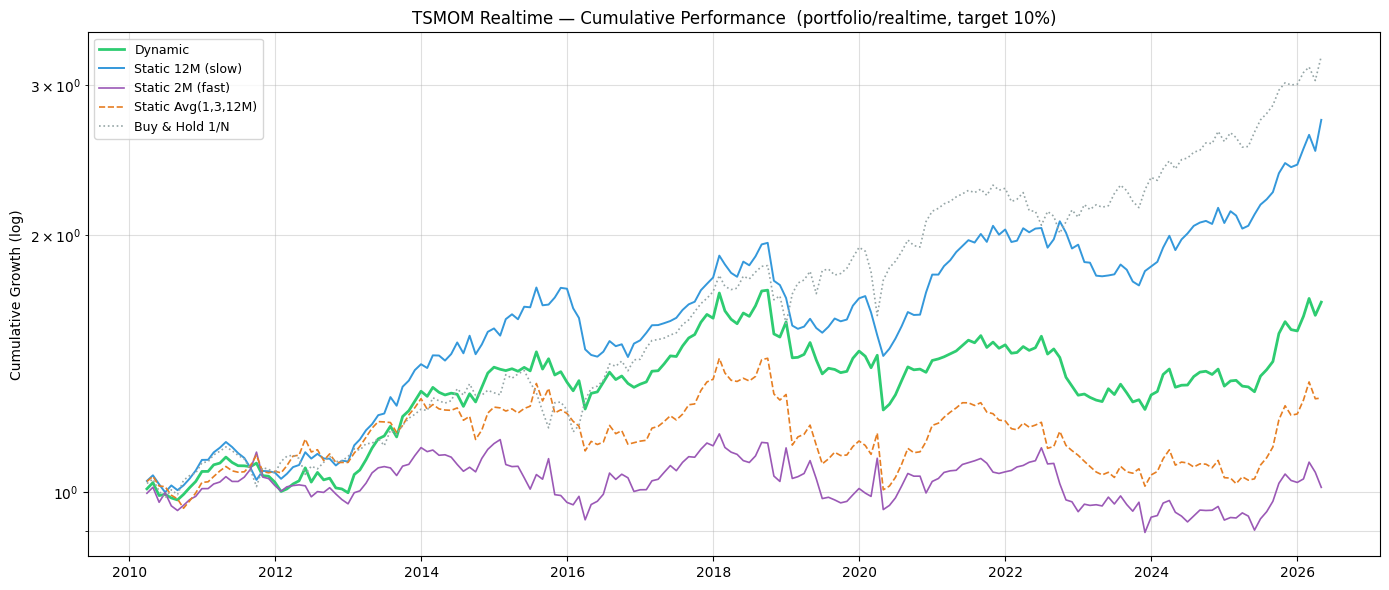

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

series_list = [
    ("Dynamic",                   port_dyn,      "#2ecc71", 2.0, "-"),
    (f"Static {cfg.K_SLOW}M (slow)", port_sta_slow, "#3498db", 1.4, "-"),
    (f"Static {cfg.K_FAST}M (fast)", port_sta_fast, "#9b59b6", 1.2, "-"),
    ("Static Avg(1,3,12M)",       port_sta_avg,  "#e67e22", 1.2, "--"),
    ("Buy & Hold 1/N",            port_bh,       "#95a5a6", 1.2, ":"),
]
for label, s, color, lw, ls in series_list:
    cum = (1 + s).cumprod()
    ax.plot(cum.index, cum.values, label=label, linewidth=lw, linestyle=ls, color=color)

ax.set_yscale("log")
ax.set_ylabel("Cumulative Growth (log)")
ax.set_title(f"TSMOM Realtime — Cumulative Performance  ({cfg.SCALE_LEVEL}/{cfg.VOL_MODE}, target {cfg.TARGET_VOL:.0%})")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.4, which="both")
plt.tight_layout()
plt.show()

## 5. Dynamic Portfolio Weights

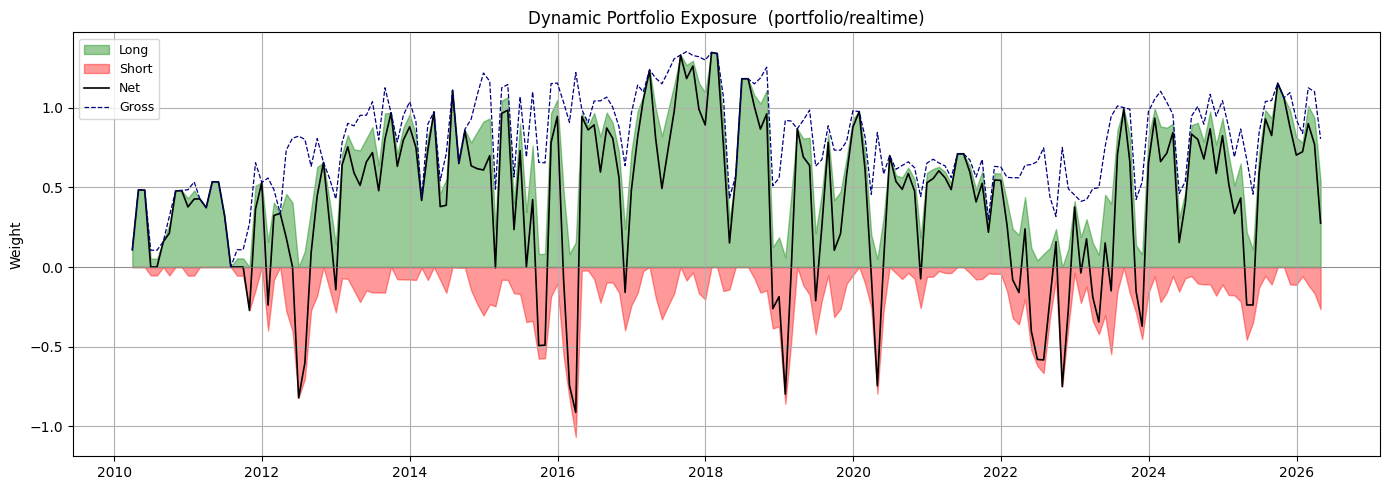

Gross leverage  : mean 78.6%  max 135.1%
Net exposure    : mean +43.9%  min -91.2%  max +134.6%


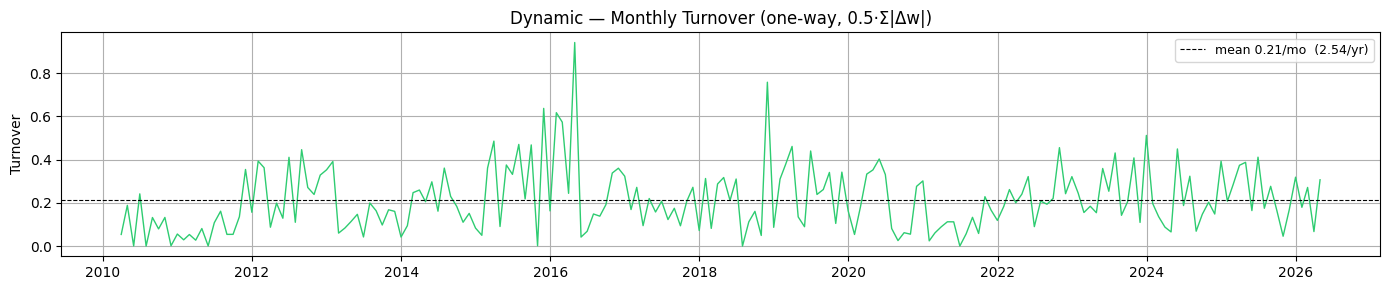

In [6]:
# Dynamic weights already computed in Section 3 (strat["Dynamic"]["weights"])
wt_dyn = strat["Dynamic"]["weights"].loc[common_idx].dropna(how="all")

# Portfolio-level gross / net / long / short over time
fig, ax = plt.subplots(figsize=(14, 5))
net_long  = wt_dyn.clip(lower=0).sum(axis=1)
net_short = wt_dyn.clip(upper=0).sum(axis=1)
net_total = net_long + net_short
gross     = wt_dyn.abs().sum(axis=1)

ax.fill_between(wt_dyn.index, net_long, alpha=0.4, color="green", label="Long")
ax.fill_between(wt_dyn.index, net_short, alpha=0.4, color="red", label="Short")
ax.plot(wt_dyn.index, net_total, color="black", linewidth=1.2, label="Net")
ax.plot(wt_dyn.index, gross, color="navy", linewidth=0.9, linestyle="--", label="Gross")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_title(f"Dynamic Portfolio Exposure  ({cfg.SCALE_LEVEL}/{cfg.VOL_MODE})")
ax.set_ylabel("Weight")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Gross leverage  : mean {gross.mean():.1%}  max {gross.max():.1%}")
print(f"Net exposure    : mean {net_total.mean():+.1%}  min {net_total.min():+.1%}  max {net_total.max():+.1%}")

# Monthly turnover time series (Dynamic)
to_dyn = strat["Dynamic"]["turnover"]
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(to_dyn.index, to_dyn.values, color="#2ecc71", linewidth=1.0)
ax.axhline(to_dyn.mean(), color="black", linestyle="--", linewidth=0.8,
           label=f"mean {to_dyn.mean():.2f}/mo  ({to_dyn.mean()*12:.2f}/yr)")
ax.set_title("Dynamic — Monthly Turnover (one-way, 0.5·Σ|Δw|)")
ax.set_ylabel("Turnover")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


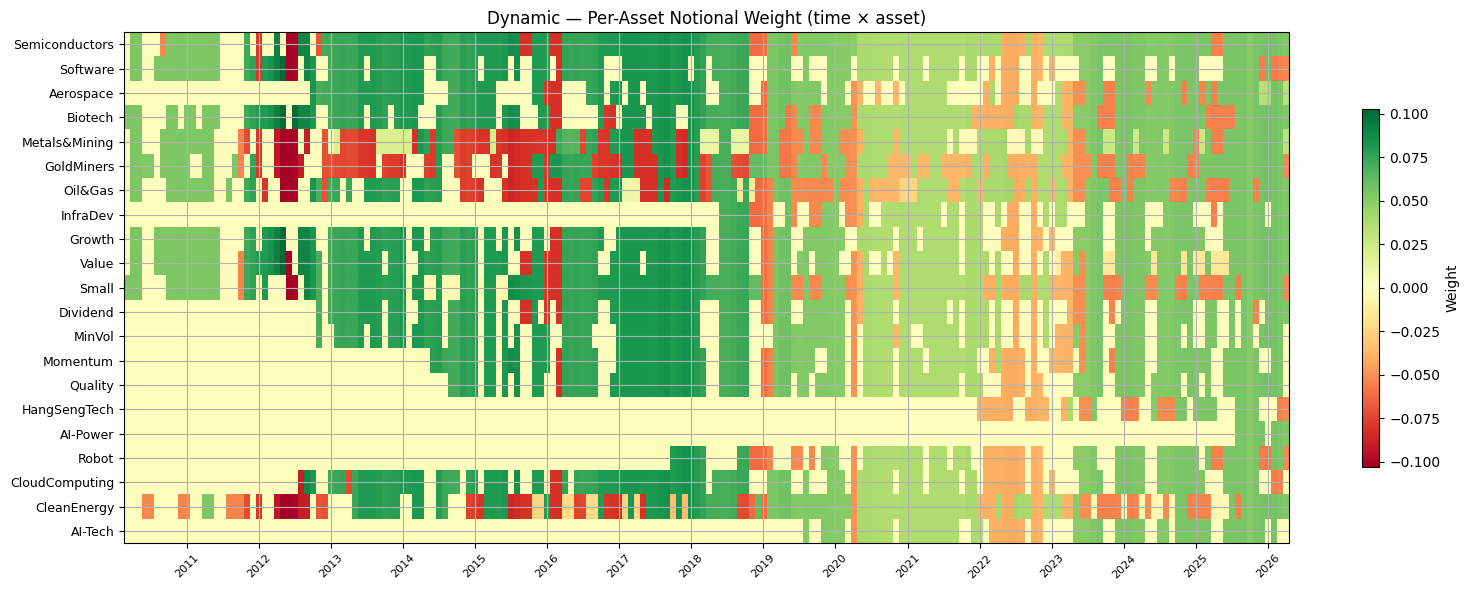

In [7]:
# Per-asset dynamic weight heatmap (time × asset)
col_labels = [cfg.TICKERS.get(t, t) for t in wt_dyn.columns]
vmax = max(abs(wt_dyn.min().min()), abs(wt_dyn.max().max()))

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(wt_dyn.T.values, aspect="auto", cmap="RdYlGn",
               vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_yticks(range(len(col_labels)))
ax.set_yticklabels(col_labels, fontsize=9)

year_ticks = [i for i, d in enumerate(wt_dyn.index) if d.month == 1]
ax.set_xticks(year_ticks)
ax.set_xticklabels([wt_dyn.index[i].year for i in year_ticks], fontsize=8, rotation=45)
ax.set_title("Dynamic — Per-Asset Notional Weight (time × asset)")
plt.colorbar(im, ax=ax, shrink=0.7, label="Weight")
plt.tight_layout()
plt.show()

## 6. Mixing Parameters (aCo, aRe)

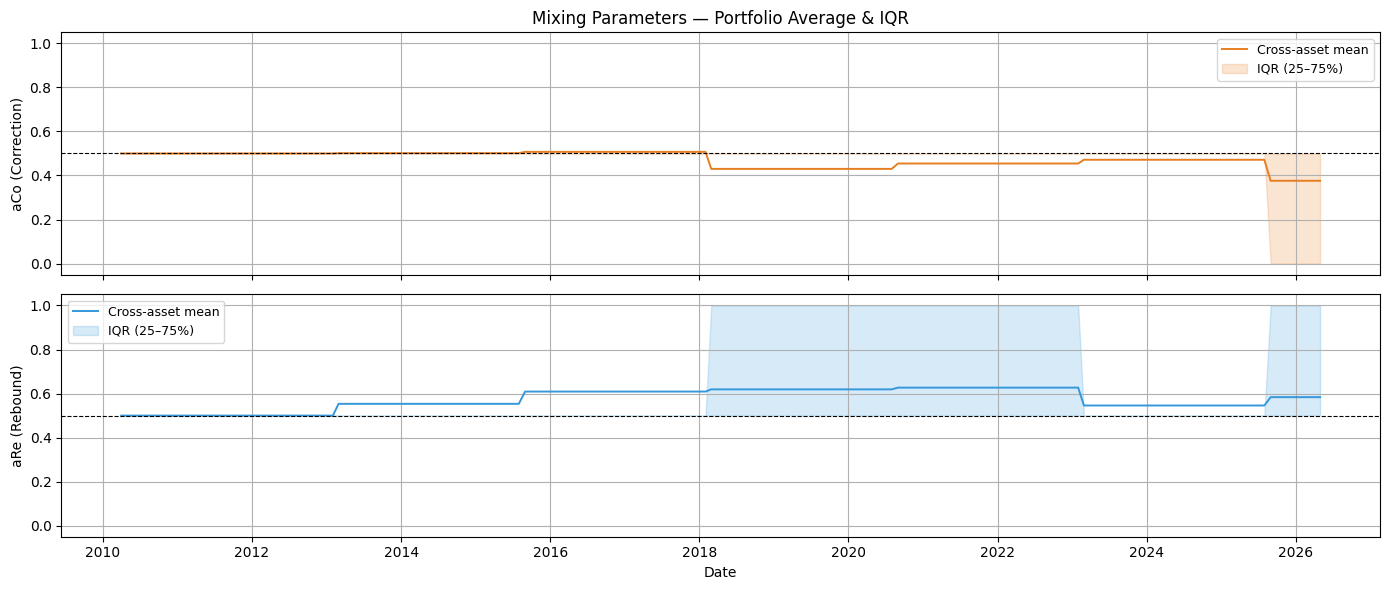

In [8]:
a_co = result["a_co"].loc[common_idx]
a_re = result["a_re"].loc[common_idx]

# Portfolio average (cross-asset mean)
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(a_co.index, a_co.mean(axis=1), color="#e67e22", linewidth=1.4, label="Cross-asset mean")
axes[0].fill_between(a_co.index, a_co.quantile(0.25, axis=1), a_co.quantile(0.75, axis=1),
                      alpha=0.2, color="#e67e22", label="IQR (25–75%)")
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[0].set_ylabel("aCo (Correction)")
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(loc="best", fontsize=9)
axes[0].set_title("Mixing Parameters — Portfolio Average & IQR")

axes[1].plot(a_re.index, a_re.mean(axis=1), color="#3498db", linewidth=1.4, label="Cross-asset mean")
axes[1].fill_between(a_re.index, a_re.quantile(0.25, axis=1), a_re.quantile(0.75, axis=1),
                      alpha=0.2, color="#3498db", label="IQR (25–75%)")
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[1].set_ylabel("aRe (Rebound)")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(loc="best", fontsize=9)
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

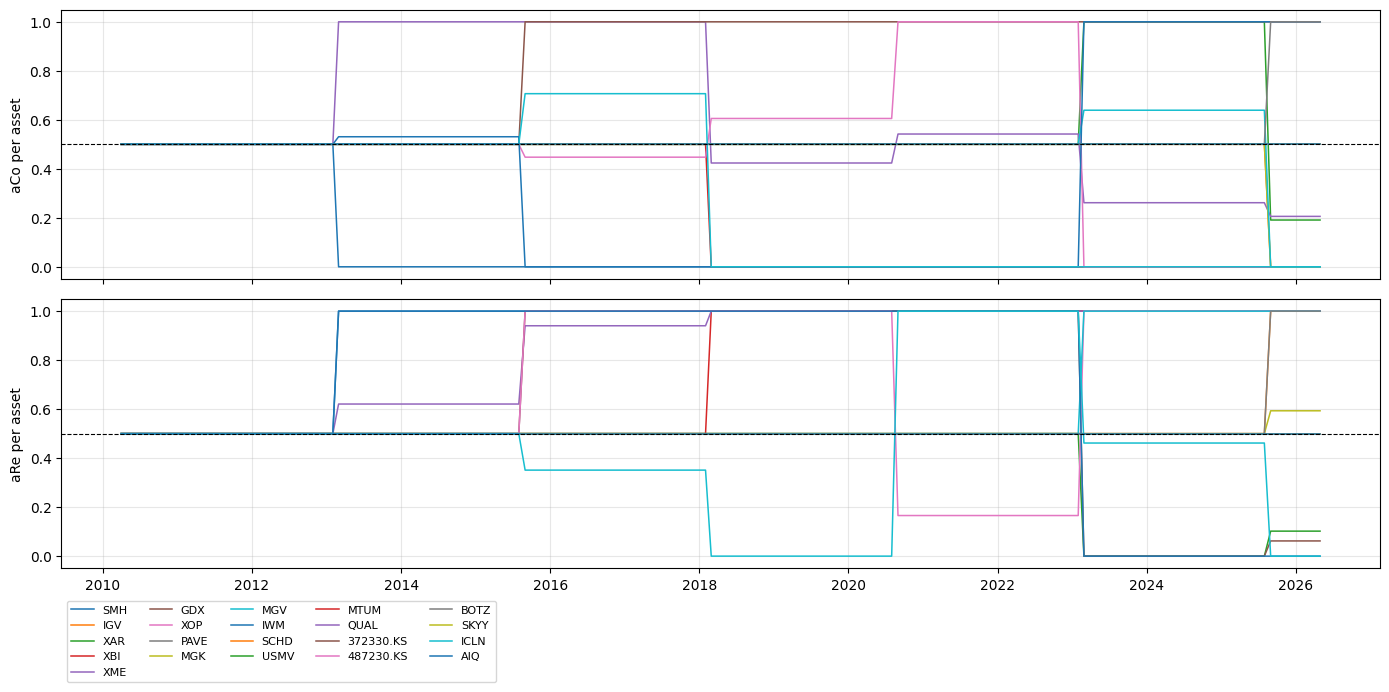

Latest mixing parameters (as of 2026-04):
            a_co   a_re  Co_tilt  Re_tilt
Ticker                                   
SMH        0.000  1.000     slow     fast
IGV        0.000  1.000     slow     fast
XAR        0.191  0.102     slow     slow
XBI        0.000  1.000     slow     fast
XME        0.206  1.000     slow     fast
GDX        1.000  0.062     fast     slow
XOP        0.000  1.000     slow     fast
PAVE       0.500  0.500  neutral  neutral
MGK        0.000  0.593     slow     fast
MGV        0.000  1.000     slow     fast
IWM        1.000  0.000     fast     slow
SCHD       0.500  0.500  neutral  neutral
USMV       0.500  0.500  neutral  neutral
MTUM       0.500  0.500  neutral  neutral
QUAL       0.500  0.500  neutral  neutral
372330.KS  0.500  0.500  neutral  neutral
487230.KS  0.500  0.500  neutral  neutral
BOTZ       1.000  1.000     fast     fast
SKYY       0.500  0.500  neutral  neutral
ICLN       0.000  0.000     slow     slow
AIQ        0.500  0.500  neutral  

In [9]:
# Per-asset aCo / aRe history (all config assets, since the universe is curated)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
cmap = plt.cm.tab10
colors = [cmap(i % 10) for i in range(len(a_co.columns))]

for i, col in enumerate(a_co.columns):
    axes[0].plot(a_co.index, a_co[col], color=colors[i], linewidth=1.1, label=col)
    axes[1].plot(a_re.index, a_re[col], color=colors[i], linewidth=1.1, label=col)

for ax, title in zip(axes, ["aCo per asset", "aRe per asset"]):
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
    ax.set_ylabel(title)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=8, ncol=5, bbox_to_anchor=(0, -0.1) if ax is axes[1] else None)

axes[0].legend_.remove()
plt.tight_layout()
plt.show()

# Latest snapshot
latest_params = pd.DataFrame({
    "a_co": a_co.iloc[-1],
    "a_re": a_re.iloc[-1],
}).round(3)
latest_params["Co_tilt"] = latest_params["a_co"].apply(
    lambda x: "slow" if x < 0.5 else ("fast" if x > 0.5 else "neutral"))
latest_params["Re_tilt"] = latest_params["a_re"].apply(
    lambda x: "slow" if x < 0.5 else ("fast" if x > 0.5 else "neutral"))
print(f"Latest mixing parameters (as of {a_co.index[-1].strftime('%Y-%m')}):")
print(latest_params.to_string())

## 7. Recent 12 Months — States & Weights

/tmp/ipykernel_35678/1902188216.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  state_mat = recent_states.replace(state_to_int).astype(float).T.values


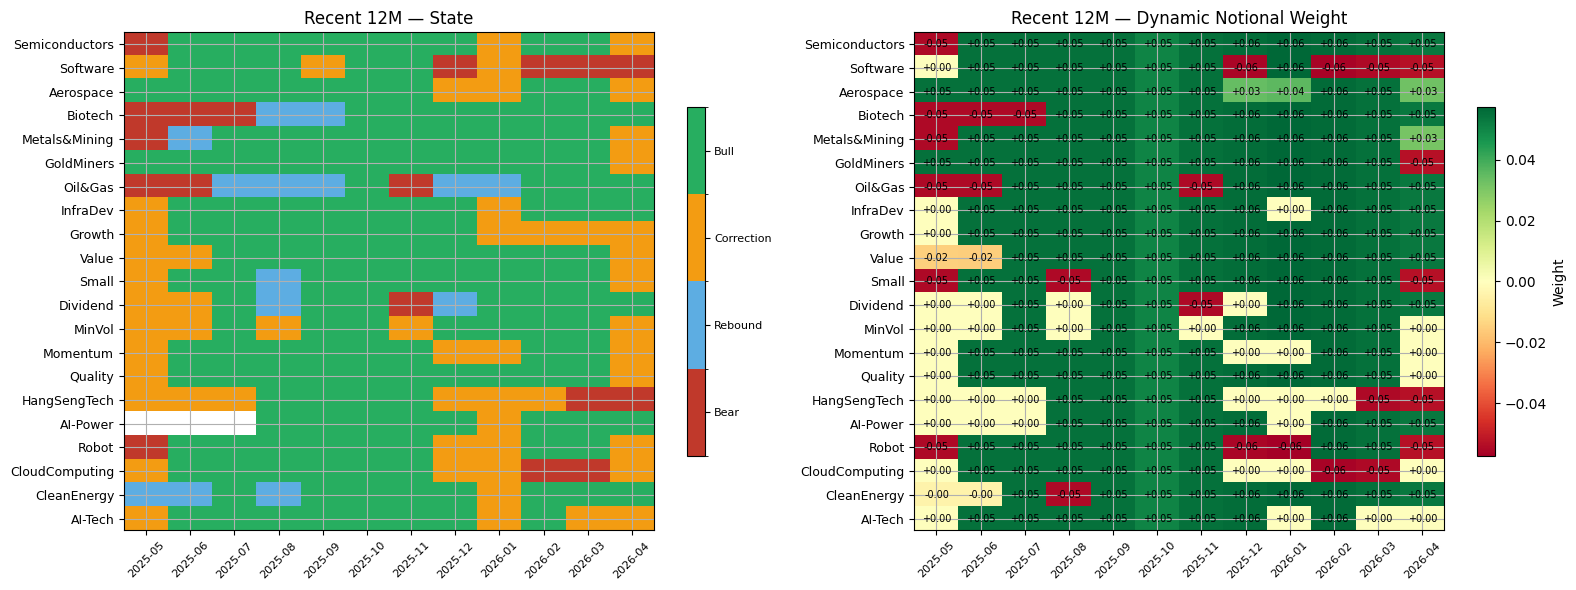

In [10]:
# Last 12 months of per-asset states and dynamic notional weights
recent_idx = wt_dyn.index[-12:]
recent_states = result["states"].loc[recent_idx]
recent_wt = wt_dyn.loc[recent_idx]

state_to_int = {"Bull": 3, "Correction": 2, "Rebound": 1, "Bear": 0}
state_colors = ["#c0392b", "#5dade2", "#f39c12", "#27ae60"]  # Bear, Rebound, Correction, Bull
state_cmap = mcolors.ListedColormap(state_colors)
state_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], state_cmap.N)

state_mat = recent_states.replace(state_to_int).astype(float).T.values

col_labels = [cfg.TICKERS.get(t, t) for t in recent_wt.columns]
date_labels = [d.strftime("%Y-%m") for d in recent_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) State heatmap
im0 = axes[0].imshow(state_mat, aspect="auto", cmap=state_cmap, norm=state_norm,
                      interpolation="nearest")
axes[0].set_yticks(range(len(col_labels)))
axes[0].set_yticklabels(col_labels, fontsize=9)
axes[0].set_xticks(range(len(date_labels)))
axes[0].set_xticklabels(date_labels, fontsize=8, rotation=45)
axes[0].set_title("Recent 12M — State")
cbar0 = plt.colorbar(im0, ax=axes[0], ticks=[0, 1, 2, 3], shrink=0.7)
cbar0.ax.set_yticklabels(["Bear", "Rebound", "Correction", "Bull"], fontsize=8)

# (b) Weight heatmap
vmax = max(abs(recent_wt.min().min()), abs(recent_wt.max().max()))
im1 = axes[1].imshow(recent_wt.T.values, aspect="auto", cmap="RdYlGn",
                      vmin=-vmax, vmax=vmax, interpolation="nearest")
axes[1].set_yticks(range(len(col_labels)))
axes[1].set_yticklabels(col_labels, fontsize=9)
axes[1].set_xticks(range(len(date_labels)))
axes[1].set_xticklabels(date_labels, fontsize=8, rotation=45)
axes[1].set_title("Recent 12M — Dynamic Notional Weight")
plt.colorbar(im1, ax=axes[1], shrink=0.7, label="Weight")

# Annotate numeric weights
for i in range(recent_wt.shape[1]):
    for j in range(recent_wt.shape[0]):
        v = recent_wt.iloc[j, i]
        if pd.notna(v):
            axes[1].text(j, i, f"{v:+.2f}", ha="center", va="center",
                         fontsize=7, color="black")

plt.tight_layout()
plt.show()

In [11]:
# Latest month detail table
latest = recent_idx[-1]
detail = pd.DataFrame({
    "Asset Class": [cfg.TICKERS[t] for t in recent_wt.columns],
    "State":       result["states"].loc[latest].values,
    "Position":    result["pos_dynamic"].loc[latest].round(3).values,
    "Weight":      recent_wt.loc[latest].round(4).values,
    "a_co":        a_co.loc[latest].round(3).values,
    "a_re":        a_re.loc[latest].round(3).values,
}, index=recent_wt.columns)
detail.index.name = "Ticker"

print(f"=== Latest month snapshot: {latest.strftime('%Y-%m')} ===")
print(detail.to_string())

gross_now = recent_wt.loc[latest].abs().sum()
net_now   = recent_wt.loc[latest].sum()
print(f"\nLatest gross: {gross_now:.1%}   net: {net_now:+.1%}")

=== Latest month snapshot: 2026-04 ===
              Asset Class       State  Position  Weight   a_co   a_re
Ticker                                                               
SMH        Semiconductors  Correction     1.000  0.0529  0.000  1.000
IGV              Software        Bear    -1.000 -0.0529  0.000  1.000
XAR             Aerospace  Correction     0.618  0.0327  0.191  0.102
XBI               Biotech        Bull     1.000  0.0529  0.000  1.000
XME         Metals&Mining  Correction     0.589  0.0311  0.206  1.000
GDX            GoldMiners  Correction    -1.000 -0.0529  1.000  0.062
XOP               Oil&Gas        Bull     1.000  0.0529  0.000  1.000
PAVE             InfraDev        Bull     1.000  0.0529  0.500  0.500
MGK                Growth  Correction     1.000  0.0529  0.000  0.593
MGV                 Value  Correction     1.000  0.0529  0.000  1.000
IWM                 Small  Correction    -1.000 -0.0529  1.000  0.000
SCHD             Dividend        Bull     1.000  0.

In [12]:
wt_dyn

Ticker,SMH,IGV,XAR,XBI,XME,GDX,XOP,PAVE,MGK,MGV,...,SCHD,USMV,MTUM,QUAL,372330.KS,487230.KS,BOTZ,SKYY,ICLN,AIQ
Date,,,,,,,,,,,,,,,,,,,,,
2010-03-31,0.000000,0.000000,0.000000,0.053836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-04-30,0.053800,0.053800,0.000000,0.053800,0.053800,0.053800,0.053800,0.000000,0.053800,0.053800,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-05-31,0.053652,0.053652,0.000000,0.053652,0.053652,0.053652,0.053652,0.000000,0.053652,0.053652,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-06-30,0.000000,0.000000,0.000000,0.000000,0.000000,0.052649,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.052649,0.000000
2010-07-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.052681,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.052681,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31,0.055636,-0.055636,0.034394,0.055636,0.055636,0.055636,0.055636,0.055636,0.055636,0.055636,...,0.000000,0.055636,0.000000,0.055636,0.000000,0.055636,-0.055636,0.000000,0.055636,0.055636
2026-01-31,0.057316,0.057316,0.035432,0.057316,0.057316,0.057316,0.057316,0.000000,0.057316,0.057316,...,0.057316,0.057316,0.000000,0.057316,0.000000,0.000000,-0.057316,0.000000,0.057316,0.000000
2026-02-28,0.056196,-0.056196,0.056196,0.056196,0.056196,0.056196,0.056196,0.056196,0.056196,0.056196,...,0.056196,0.056196,0.056196,0.056196,0.000000,0.056196,0.056196,-0.056196,0.056196,0.056196
